# Change detection in optical satellite time series - Tutorial

<div align="center">
  
  <!-- Institution Logos -->
  <img src="https://www.umr-lastig.fr/static/lastig_1920_EN-5022e6685c1e4b6d7e84d2a08667be4e.png" height="60" alt="LASTIG">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://iadf-school.org/wp-content/uploads/2022/09/logo_iadfschool.png" height="60" alt="IADF School">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://design-system.ign.fr/img/styleguide/sg_logos/IGN_logo_RVB.png" height="60" alt="IGN">
  
  <br><br>
  
  <!-- Colab Badge -->
  [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElliotVincent/iadfschool26tutorial/tutorial01.ipynb)
  
  
</div>

---

## **Tutorial 1: Training**

**Welcome to Tutorial 1!** In this hands-on session, you'll learn how to train a model for Super-Resolution for Sentinel-2 multispectral remote sensing images. This tutorial will guide you through the complete pipeline from data preparation to model training and evaluation.

### What You'll Learn
- 🛰️ Working with Sentinel-2 multispectral imagery
- 🔬 Understanding super-resolution techniques for remote sensing
- 🧠 Training deep learning models for image enhancement
- 📊 Evaluating model performance and trustworthiness
- 🎯 Practical implementation in Google Colab

### Prerequisites
- Basic knowledge of Python and deep learning
- Familiarity with remote sensing concepts
- Google account for Colab access

---

## Introduction

This tutorial demonstrates how to perform change detection in optical satellite time series using Python.  
We will use a sample dataset of satellite images and apply various techniques to identify changes over time.  
The sample dataset is extracted from DynamicEarthNet [1] and focuses on 3 AoIs.  
The map below shows the location of the 3 AoIs in the world:  


![Map of the 3 AoIs](aois_location.png)


In [1]:
# Import necessary libraries
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt

## 1. Playing with Satellite Image Time Series

### 1.1. Loading and Visualizing the Dataset

In [44]:
DYNAMICEARTHNET_CLASSES = {
    0: {"label": "impervious surface",       "color": (128, 128, 128)},  # grey
    1: {"label": "agriculture",               "color": (255, 214,   0)},  # yellow
    2: {"label": "forest & other vegetation", "color": ( 34, 139,  34)},  # green
    3: {"label": "soil",                      "color": (139,  90,  43)},  # brown
    4: {"label": "water",                     "color": ( 31, 119, 180)},  # blue
}

DATES = [f"{yyyy}-{mm:02d}-01" for yyyy in range(2018, 2020) for mm in range(1, 13)]

# Utility function to perform percentile stretching on the image for better visualization
def percentile_stretch(img, low=2, high=98):
    lo, hi = np.percentile(img, (low, high))
    img_clipped = np.clip(img, lo, hi)
    return ((img_clipped - lo) / (hi - lo) * 255).astype(np.uint8)

# Function to plot a single image
def plot_image(image):
    rgb_img = image[[2, 1, 0], :, :]
    rgb_img = rgb_img.transpose(1, 2, 0)
    rgb_img = percentile_stretch(rgb_img)
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.show()

# Function to plot a single label
def plot_labels(label):
    rgb_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for i in range(5):
        rgb_label[label == i] = DYNAMICEARTHNET_CLASSES[i]["color"]
    plt.imshow(rgb_label)
    plt.axis('off')
    plt.show()

# Function to plot a time series of images and labels
def plot_time_series(images, labels, num_images=10):
    num_images = min(num_images, len(images))
    fig, axes = plt.subplots(3, num_images, figsize=(int(4*num_images / 3), 4))
    for i in range(num_images):
        # Plot the image
        rgb_img = images[i, :3].transpose(1, 2, 0)
        rgb_img = percentile_stretch(rgb_img)
        axes[0, i].set_title(DATES[i], fontsize=10)
        axes[0, i].imshow(rgb_img)
        axes[0, i].axis('off')

        # Plot the semantic maps
        rgb_label = np.zeros((labels[i].shape[0], labels[i].shape[1], 3), dtype=np.uint8)
        for j in range(5):
            rgb_label[labels[i] == j] = DYNAMICEARTHNET_CLASSES[j]["color"]
        axes[1, i].imshow(rgb_label)
        axes[1, i].axis('off')

        # Plot binary change maps
        if i > 0:
            change_map = (labels[i] != labels[i-1]).astype(np.uint8) * 255
            axes[2, i].imshow(change_map, cmap='gray')
            axes[2, i].axis('off')
        else:
            axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

def load_time_series(path):
    return np.stack([rasterio.open(f"{path}/{date}.tif").read() for date in DATES], axis=0)[:, [2, 1, 0, 3]]

def load_labels(path):
    labels = np.load(f'{path}.npy')
    labels = np.where(labels == 4, 3, labels)
    labels = np.where(labels == 5, 4, labels)
    return labels

We first load the sample dataset and visualize the images for each AoI.  
Satellite image time series (SITS) are stored as T x C x H x W tensors, where T is the number of time steps, C is the number of channels (spectral bands), H is the height, and W is the width of the image.  
In our case, we have 3 AoIs with T=24 (2 years of monthly images), C=4 (RGB + NIR), H=1024, and W=1024.  
The spatial resolution of the images is roughly 3 meters per pixel.

Loading train images and labels...


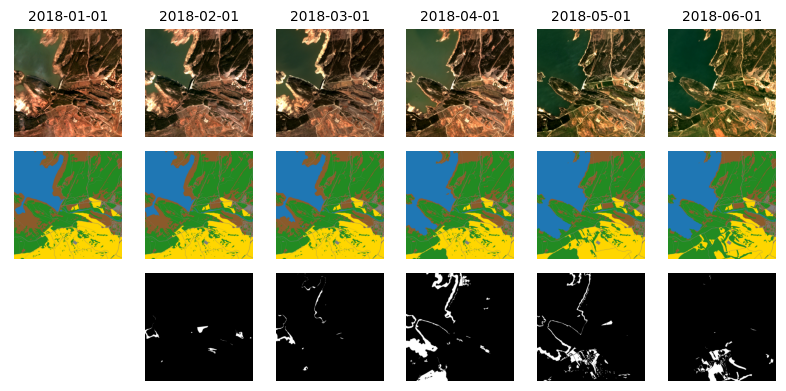

Loading validation images and labels...


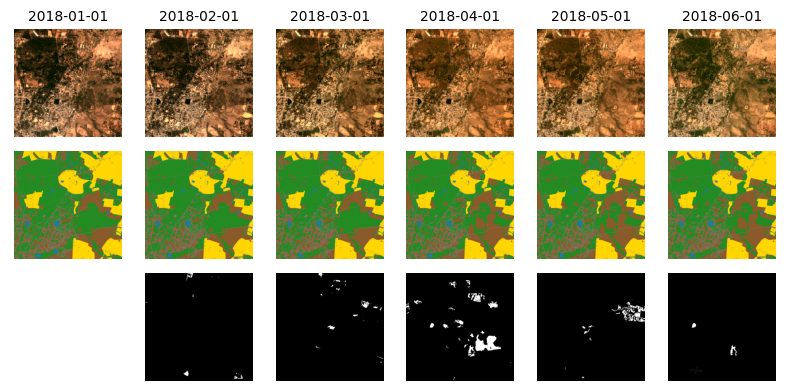

Loading test images and labels...


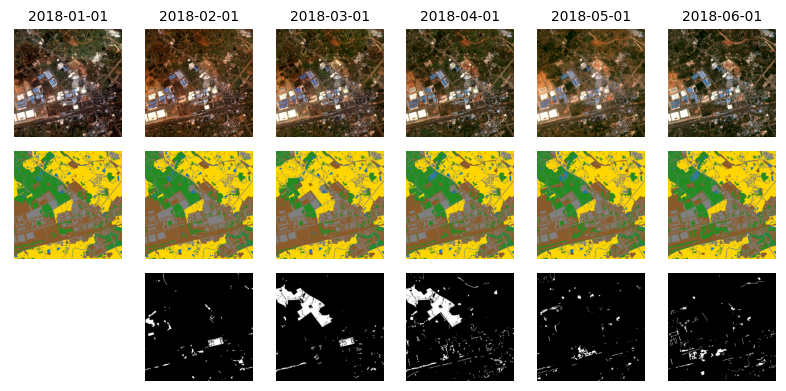

In [45]:
aoi_1 = '3998_3016_13'
aoi_2 = '5989_3554_13'
aoi_3 = '6468_3360_13'

print(f"Loading train images and labels...")
aoi_1_images = load_time_series(aoi_1)
aoi_1_labels = load_labels(aoi_1)
plot_time_series(aoi_1_images, aoi_1_labels, num_images=6)

print(f"Loading validation images and labels...")
aoi_2_images = load_time_series(aoi_2)
aoi_2_labels = load_labels(aoi_2)
plot_time_series(aoi_2_images, aoi_2_labels, num_images=6)

print(f"Loading test images and labels...")
aoi_3_images = load_time_series(aoi_3)
aoi_3_labels = load_labels(aoi_3)
plot_time_series(aoi_3_images, aoi_3_labels, num_images=6)


Let's check the shape of each SITS tensor.

In [46]:
print(f"AOI 1 images shape: {aoi_1_images.shape}, AOI 1 labels shape: {aoi_1_labels.shape}")
print(f"AOI 2 images shape: {aoi_2_images.shape}, AOI 2 labels shape: {aoi_2_labels.shape}")
print(f"AOI 3 images shape: {aoi_3_images.shape}, AOI 3 labels shape: {aoi_3_labels.shape}")

AOI 1 images shape: (24, 4, 1024, 1024), AOI 1 labels shape: (24, 1024, 1024)
AOI 2 images shape: (24, 4, 1024, 1024), AOI 2 labels shape: (24, 1024, 1024)
AOI 3 images shape: (24, 4, 1024, 1024), AOI 3 labels shape: (24, 1024, 1024)


### 1.2. Playing with spectral indices

Now that we have loaded the dataset, we can start exploring the data and applying change detection techniques.  
First, let's visualize the per-class NDVI and NDWI averaged time series for the AOI 1.
NDVI (Normalized Difference Vegetation Index) and NDWI (Normalized Difference Water Index) are commonly used indices in remote sensing to assess vegetation health and water content, respectively.
They are calculated using the following formulas:
- NDVI = (NIR - Red) / (NIR + Red)
- NDWI = (Green - NIR) / (Green + NIR)

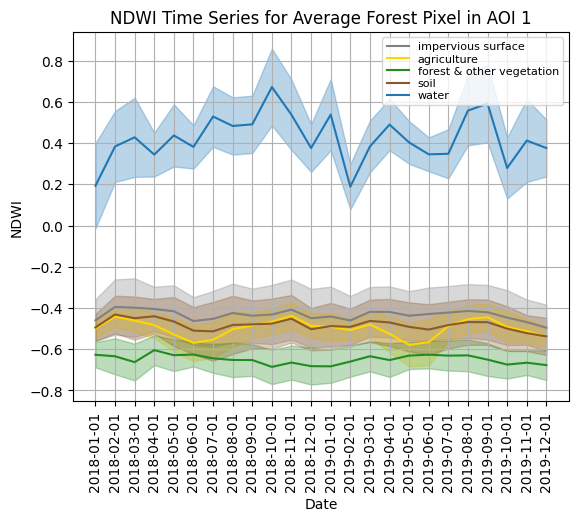

In [47]:
binary_change_maps = (aoi_1_labels[1:] != aoi_1_labels[:-1]).sum(axis=0)
for class_id, class_info in DYNAMICEARTHNET_CLASSES.items():
    curr_pixel_indices = np.where((aoi_1_labels[0] == class_id) & (binary_change_maps == 0))
    pixel_time_series = aoi_1_images[..., curr_pixel_indices[0], curr_pixel_indices[1]]
    ndwi_time_series = (pixel_time_series[:, 1] - pixel_time_series[:, 3]) / (pixel_time_series[:, 1] + pixel_time_series[:, 3])  # NDWI = (Green - NIR) / (Green + NIR)
    ndwi_time_series_mean = ndwi_time_series.mean(axis=1)  # Average over all pixels
    ndwi_time_series_std = ndwi_time_series.std(axis=1)  # Standard deviation over all pixels
    plt.plot(DATES, ndwi_time_series_mean, color=np.array(class_info["color"])/255, label=class_info["label"])
    plt.fill_between(DATES, ndwi_time_series_mean - ndwi_time_series_std, ndwi_time_series_mean + ndwi_time_series_std, color=np.array(class_info["color"])/255, alpha=0.3)
    plt.title(f"NDWI Time Series for Average Forest Pixel in AOI 1")
plt.xlabel("Date")
plt.ylabel("NDWI")
plt.xticks(rotation=90)
plt.grid()
plt.legend(loc='upper right', labelspacing=.2, fontsize=8)
plt.show()


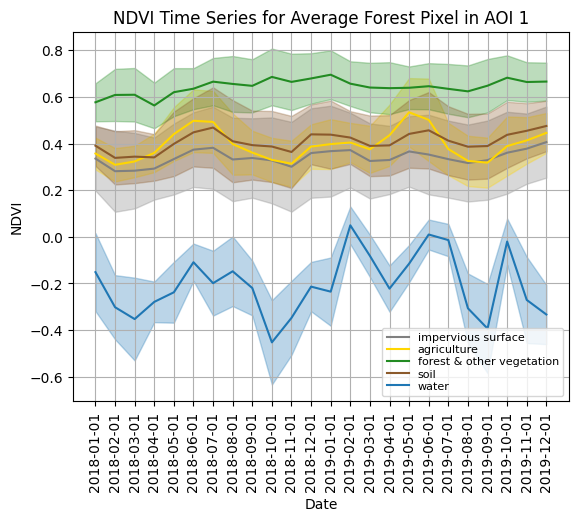

In [48]:
binary_change_maps = (aoi_1_labels[1:] != aoi_1_labels[:-1]).sum(axis=0)
for class_id, class_info in DYNAMICEARTHNET_CLASSES.items():
    curr_pixel_indices = np.where((aoi_1_labels[0] == class_id) & (binary_change_maps == 0))
    pixel_time_series = aoi_1_images[..., curr_pixel_indices[0], curr_pixel_indices[1]]
    ndvi_time_series = (pixel_time_series[:, 3] - pixel_time_series[:, 0]) / (pixel_time_series[:, 3] + pixel_time_series[:, 0])  # NDVI = (NIR - Red) / (NIR + Red)
    ndvi_time_series_mean = ndvi_time_series.mean(axis=1)  # Average over all pixels
    ndvi_time_series_std = ndvi_time_series.std(axis=1)  # Standard deviation over all pixels
    plt.plot(DATES, ndvi_time_series_mean, color=np.array(class_info["color"])/255, label=class_info["label"])
    plt.fill_between(DATES, ndvi_time_series_mean - ndvi_time_series_std, ndvi_time_series_mean + ndvi_time_series_std, color=np.array(class_info["color"])/255, alpha=0.3)
    plt.title(f"NDVI Time Series for Average Forest Pixel in AOI 1")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.xticks(rotation=90)
plt.grid()
plt.legend(loc='lower right', labelspacing=.2, fontsize=8)
plt.show()


As expected, the NDWI index allows to clearly distinguish between water and non-water classes, while the NDVI also isolates the vegetation classes from the non-vegetation ones. Visualizing the NDVI and NDWI time series for a given pixel can help to identify changes in land cover over time. For example, a sudden drop in NDVI may indicate deforestation or urbanization, while a sudden increase in NDWI may indicate flooding or the creation of a new water body.  

For example, let's plot on top of the NDWI time series, the NDWI of a selected pixel in AoI 1. This pixel is located at the given coordinates (i=400, j=400), which corresponds to a coastal area.

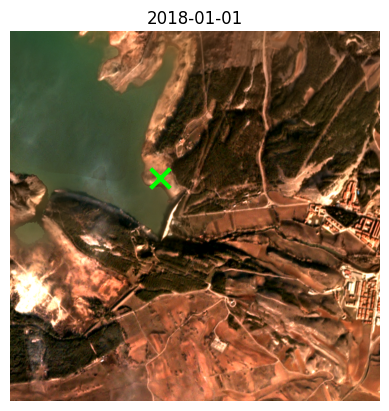

In [49]:
x, y = 415, 405

rgb_img = aoi_1_images[0, :3].transpose(1, 2, 0)
rgb_img = percentile_stretch(rgb_img)
plt.imshow(rgb_img)
plt.scatter(x, y, color='lime', marker='x', s=200, linewidth=3)
plt.title(DATES[0])
plt.axis('off')
plt.show()

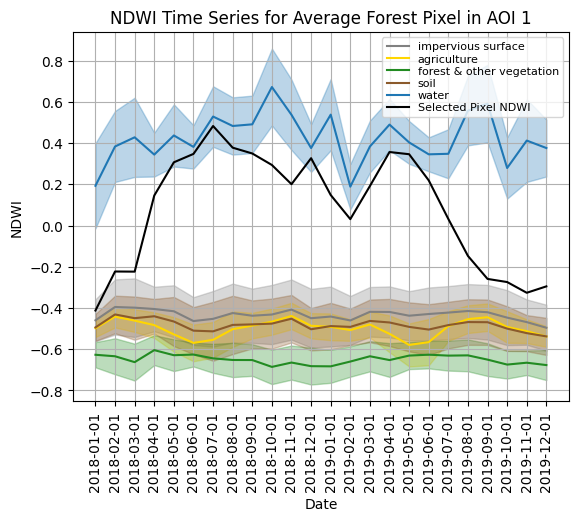

In [50]:
binary_change_maps = (aoi_1_labels[1:] != aoi_1_labels[:-1]).sum(axis=0)
for class_id, class_info in DYNAMICEARTHNET_CLASSES.items():
    curr_pixel_indices = np.where((aoi_1_labels[0] == class_id) & (binary_change_maps == 0))
    pixel_time_series = aoi_1_images[..., curr_pixel_indices[0], curr_pixel_indices[1]]
    ndwi_time_series = (pixel_time_series[:, 1] - pixel_time_series[:, 3]) / (pixel_time_series[:, 1] + pixel_time_series[:, 3])  # NDWI = (Green - NIR) / (Green + NIR)
    ndwi_time_series_mean = ndwi_time_series.mean(axis=1)  # Average over all pixels
    ndwi_time_series_std = ndwi_time_series.std(axis=1)  # Standard deviation over all pixels
    plt.plot(DATES, ndwi_time_series_mean, color=np.array(class_info["color"])/255, label=class_info["label"])
    plt.fill_between(DATES, ndwi_time_series_mean - ndwi_time_series_std, ndwi_time_series_mean + ndwi_time_series_std, color=np.array(class_info["color"])/255, alpha=0.3)
    plt.title(f"NDWI Time Series for Average Forest Pixel in AOI 1")
selected_pixel = aoi_1_images[..., y, x]
selected_pixel_ndwi = (selected_pixel[:, 1] - selected_pixel[:, 3]) / (selected_pixel[:, 1] + selected_pixel[:, 3])
plt.plot(DATES, selected_pixel_ndwi, color='black', label='Selected Pixel NDWI')
plt.xlabel("Date")
plt.ylabel("NDWI")
plt.xticks(rotation=90)
plt.grid()
plt.legend(loc='upper right', labelspacing=.2, fontsize=8)
plt.show()

This pixel seems to switch from a non-water class to a water class or vice versa at several time steps. This is a clear indication of a change in land cover, which can be further analyzed using change detection techniques.

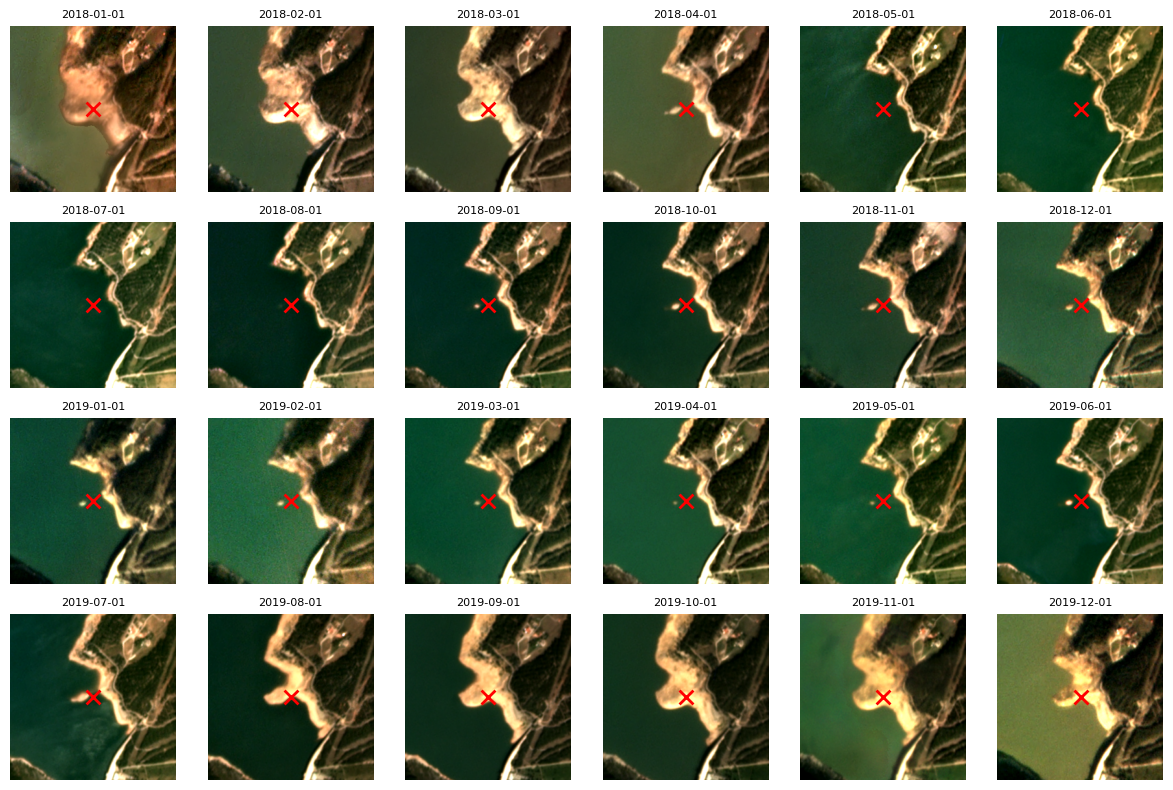

In [51]:
# Lets zoom around the selected pixel and show the images for the first 24 dates with a red cross on the selected pixel
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i in range(24):
    rgb_img = aoi_1_images[i, :3].transpose(1, 2, 0)
    rgb_img = percentile_stretch(rgb_img)
    rgb_img = rgb_img[y-128:y+128, x-128:x+128, :3]
    rgb_img = percentile_stretch(rgb_img)
    axes[i // 6, i % 6].imshow(rgb_img)
    axes[i // 6, i % 6].scatter(128, 128, color='red', marker='x', s=100, linewidth=2)
    axes[i // 6, i % 6].set_title(DATES[i], fontsize=8)
    axes[i // 6, i % 6].axis('off')
plt.tight_layout()
plt.show()

### 1.3. Shaping a dataset for SITS change detection

Spatial and temporal domain shifts are known to be a major challenge in SITS change detection: they are out of the scope of this tutorial. We build a simpler setting in which each dataset split spans all 3 AoIs and both the years 2018 and 2019. Images top half are used for training, while the bottom left and bottom right are used for validation and testing respectively.

In [52]:
class SITSDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels, split, norm=True, num_classes=5):
        # Load the dataset once in memory
        self.data = data
        self.labels = labels
        self.norm = norm
        self.mean = torch.tensor([898.4894, 825.8315, 631.3781, 2228.1465])
        self.std = torch.tensor([505.9963, 365.0649, 336.9732, 915.9556])
        self.num_classes = num_classes
        self.split = split

    def __len__(self):
        if self.split == 'train':
            return 96
        else:
            return 48

    def __getitem__(self, idx):
        aoi = idx % 3
        idx = idx // 3
        if self.split == 'train':
            quarter_i = 0
            quarter_j = idx % 2
            idx = idx // 2
        elif self.split == 'val':
            quarter_i = 1
            quarter_j = 0
        elif self.split == 'test':
            quarter_i = 1
            quarter_j = 1
        i, j = idx // 4 + quarter_i * 4, idx % 4 + quarter_j * 4
        imgs = torch.tensor(self.data[aoi][..., i*128:(i+1)*128, j*128:(j+1)*128])
        labs = torch.tensor(self.labels[aoi][..., i*128:(i+1)*128, j*128:(j+1)*128])
        if self.norm:
            imgs = (imgs - self.mean[:, None, None]) / self.std[:, None, None]
        return imgs, labs


In [53]:
train_set = SITSDataset(data=[aoi_1_images, aoi_2_images, aoi_3_images],
                        labels=[aoi_1_labels, aoi_2_labels, aoi_3_labels],
                        split='train', norm=True, num_classes=5)

val_set = SITSDataset(data=[aoi_1_images, aoi_2_images, aoi_3_images],
                      labels=[aoi_1_labels, aoi_2_labels, aoi_3_labels],
                      split='val', norm=True, num_classes=5)

test_set = SITSDataset(data=[aoi_1_images, aoi_2_images, aoi_3_images],
                      labels=[aoi_1_labels, aoi_2_labels, aoi_3_labels],
                      split='test', norm=True, num_classes=5)

In [54]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

In [55]:
import segmentation_models_pytorch as smp
import torch.nn as nn


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Base U-Net without classification head
        self.unet = smp.Unet(
            encoder_name="mobilenet_v2",    # Backbone for feature extraction
            encoder_weights='imagenet',           # Pre-trained on ImageNet
            in_channels=4,                  # 4 bands (R, G, B, NIR)
            classes=5,
            activation=None,                # No activation for regression
        )

    def forward(self, x):
        # Input x of shape (B, C, H, W)
        logits = self.unet(x)  # Shape: (B, 6, H, W)
        return logits

# Create the super-resolution model
model = UNet()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 6,629,813


In [56]:
import random

def compute_metrics(confusion_matrix):
    # Compute overall accuracy
    overall_accuracy = torch.trace(confusion_matrix) / torch.sum(confusion_matrix)

    # Compute mean IoU
    intersection = torch.diagonal(confusion_matrix)
    union = torch.sum(confusion_matrix, dim=1) + torch.sum(confusion_matrix, dim=0) - intersection
    mean_iou = torch.mean(intersection / union)
    
    return overall_accuracy, mean_iou

def training_step(batch, model, criterion, optimizer):
    imgs, labs = batch
    # imgs of shape (B, T, C, H, W)
    optimizer.zero_grad()
    temp_indices = torch.tensor([random.randint(0, imgs.size(1) - 1) for _ in range(imgs.size(0))], device=imgs.device)  # (B)
    batch_idx = torch.arange(imgs.size(0), device=imgs.device)
    imgs, labs = imgs[batch_idx, temp_indices], labs[batch_idx, temp_indices]
    logits = model.forward(imgs)
    loss = criterion(logits, labs.long())
    loss.backward()
    optimizer.step()
    return loss

def validation_step(batch, model, criterion):
    imgs, labs = batch
    # imgs of shape (1, T, C, H, W)
    imgs, labs = imgs.reshape(-1, *imgs.shape[2:]), labs.reshape(-1, *labs.shape[2:])  # Flatten the time dimension
    logits = model.forward(imgs)
    loss = criterion(logits, labs.long())
    pred = torch.argmax(logits, dim=1)
    return loss, pred, labs



In [58]:
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)
model = UNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 20

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    avg_train_loss = 0.0
    for batch in train_loader:
        loss = training_step(batch, model, criterion, optimizer)
        avg_train_loss += loss.item()
    avg_train_loss /= len(train_loader)
    print(f"   Average Training Loss: {avg_train_loss:.4f}")
    model.eval()
    avg_val_loss = 0.0
    val_conf_matrix = torch.zeros(5, 5, dtype=torch.long)
    with torch.no_grad():
        for batch in val_loader:
            loss, pred, labs = validation_step(batch, model, criterion)
            avg_val_loss += loss.item()
            val_conf_matrix += torch.bincount(pred.flatten().long() * 5 + labs.flatten().long(), minlength=25).reshape(5, 5)
    avg_val_loss /= len(val_loader)
    acc, miou = compute_metrics(val_conf_matrix)
    print(f"   Average Validation Loss: {avg_val_loss:.4f}")
    print(f"   Validation Accuracy: {acc*100:.2f}%, mIoU: {miou*100:.2f}%")

Epoch 1/20
   Average Training Loss: 1.8758
   Average Validation Loss: 1.9573
   Validation Accuracy: 26.57%, mIoU: 9.58%
Epoch 2/20
   Average Training Loss: 1.7025
   Average Validation Loss: 1.7762
   Validation Accuracy: 25.24%, mIoU: 10.05%
Epoch 3/20
   Average Training Loss: 1.5308
   Average Validation Loss: 1.6067
   Validation Accuracy: 27.09%, mIoU: 10.92%
Epoch 4/20
   Average Training Loss: 1.4537
   Average Validation Loss: 1.5418
   Validation Accuracy: 30.64%, mIoU: 14.69%
Epoch 5/20
   Average Training Loss: 1.3677
   Average Validation Loss: 1.4808
   Validation Accuracy: 35.38%, mIoU: 23.70%
Epoch 6/20
   Average Training Loss: 1.2827
   Average Validation Loss: 1.4390
   Validation Accuracy: 38.28%, mIoU: 27.20%
Epoch 7/20
   Average Training Loss: 1.2155
   Average Validation Loss: 1.3960
   Validation Accuracy: 38.61%, mIoU: 28.63%
Epoch 8/20
   Average Training Loss: 1.2391
   Average Validation Loss: 1.3670
   Validation Accuracy: 39.96%, mIoU: 30.53%
Epoch 9/2

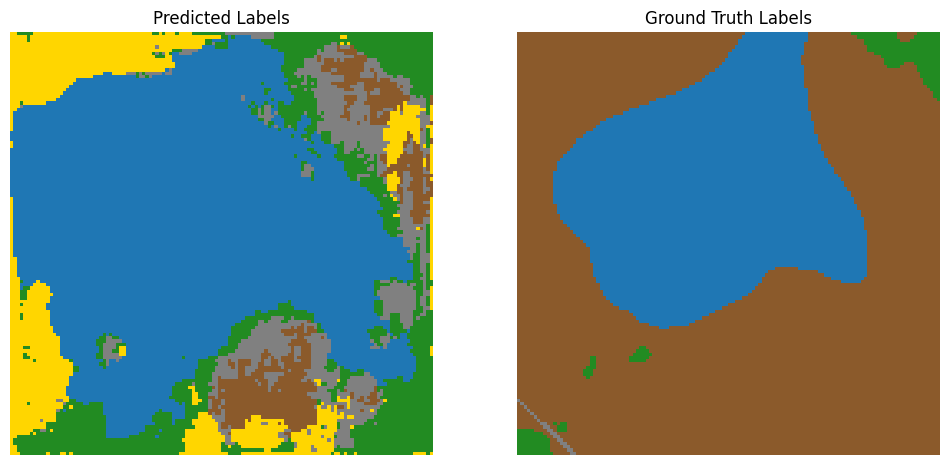

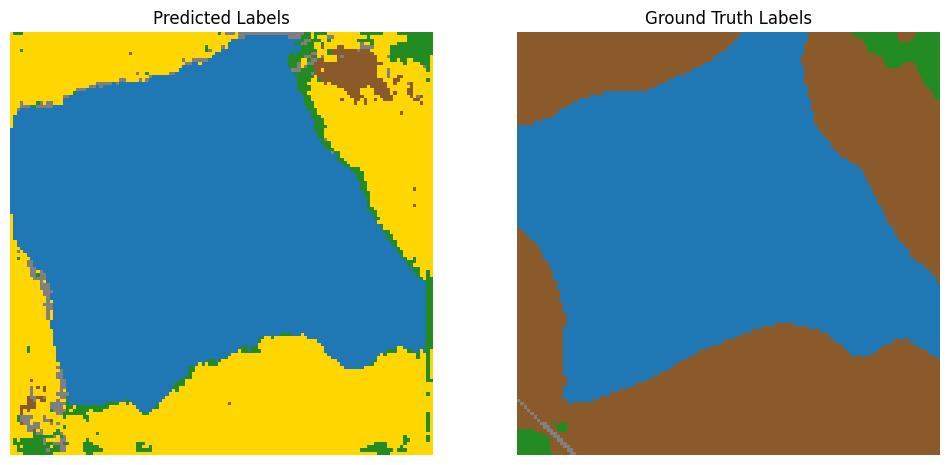

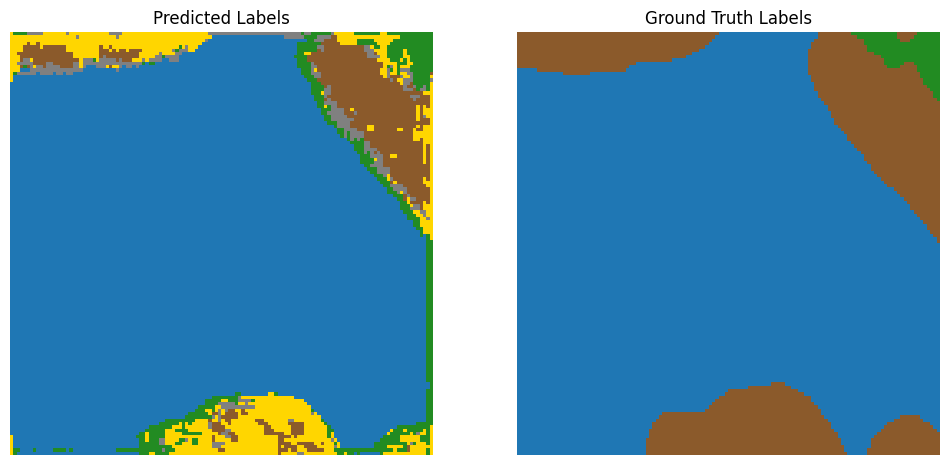

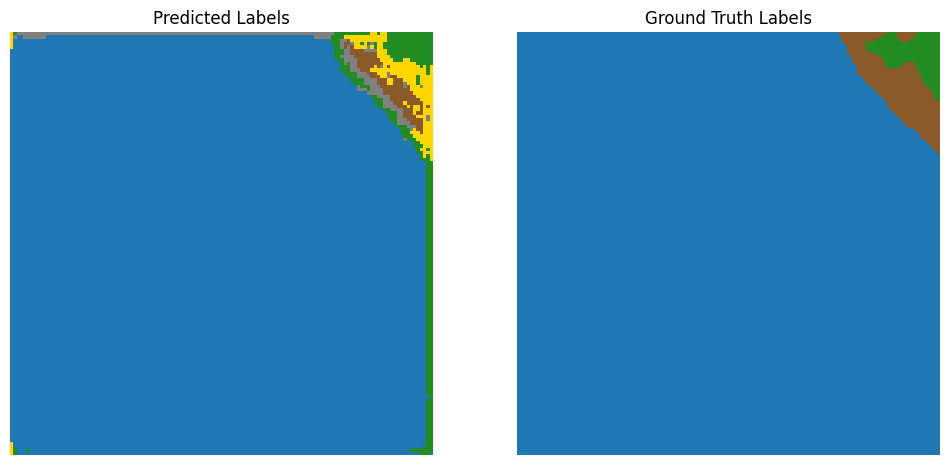

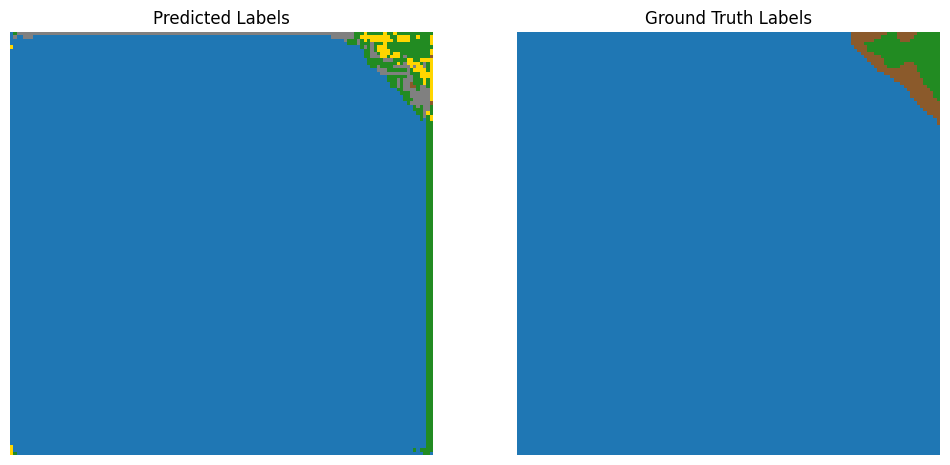

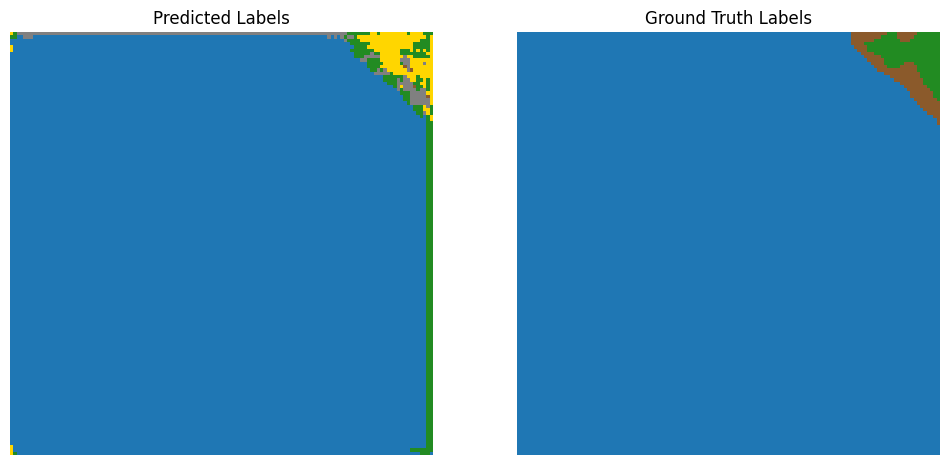

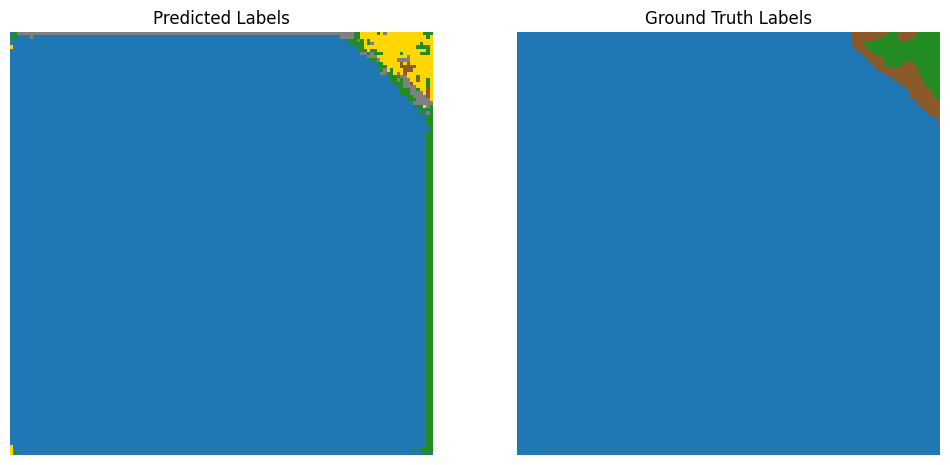

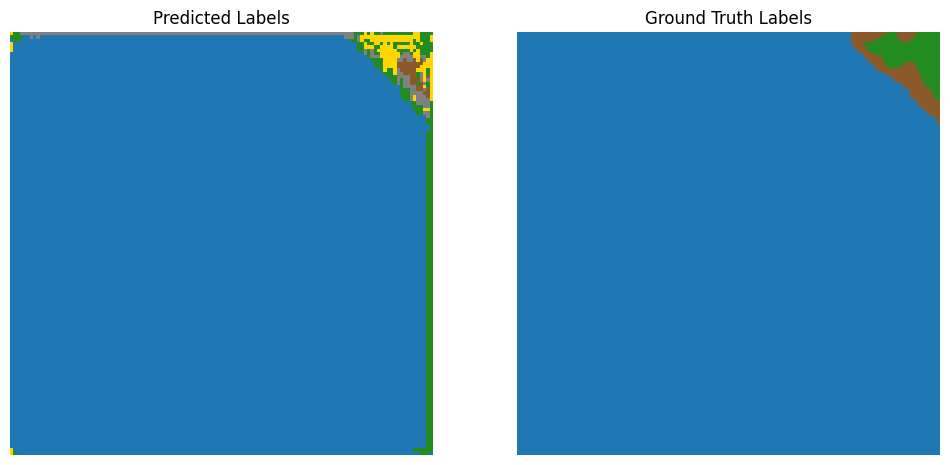

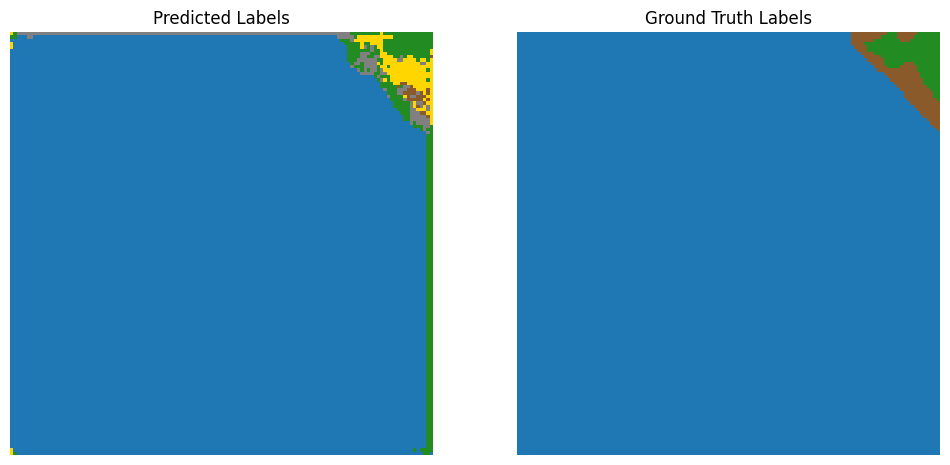

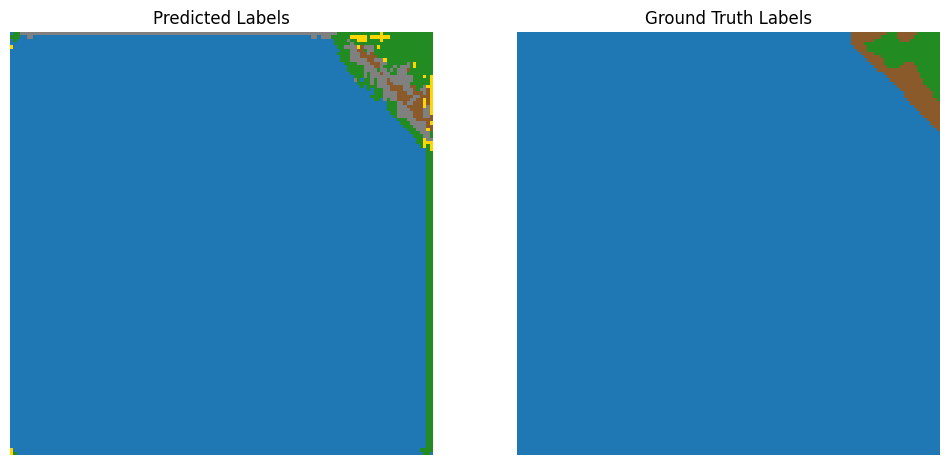

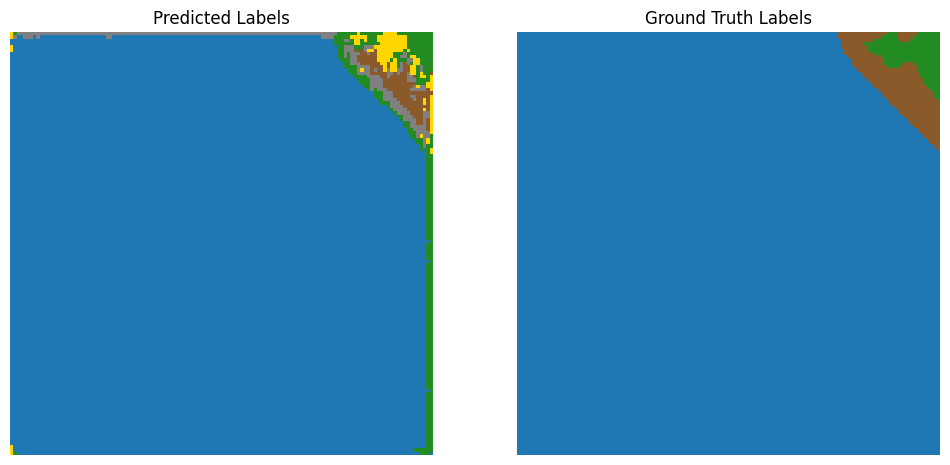

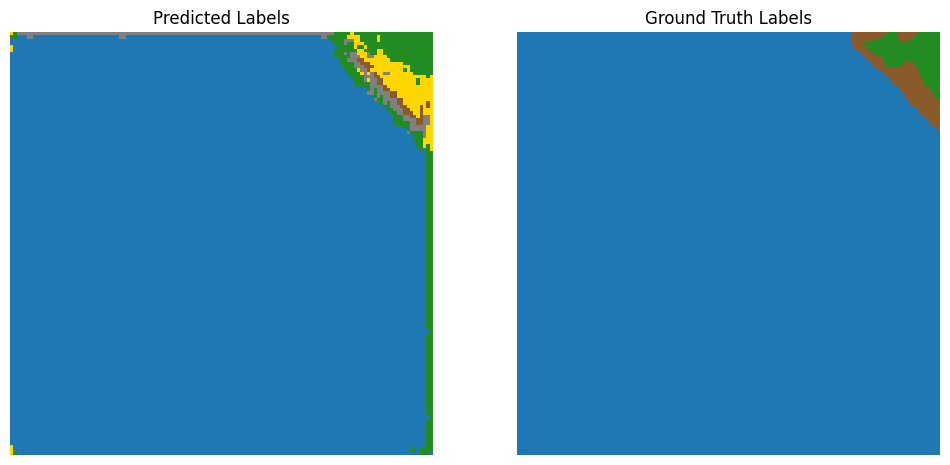

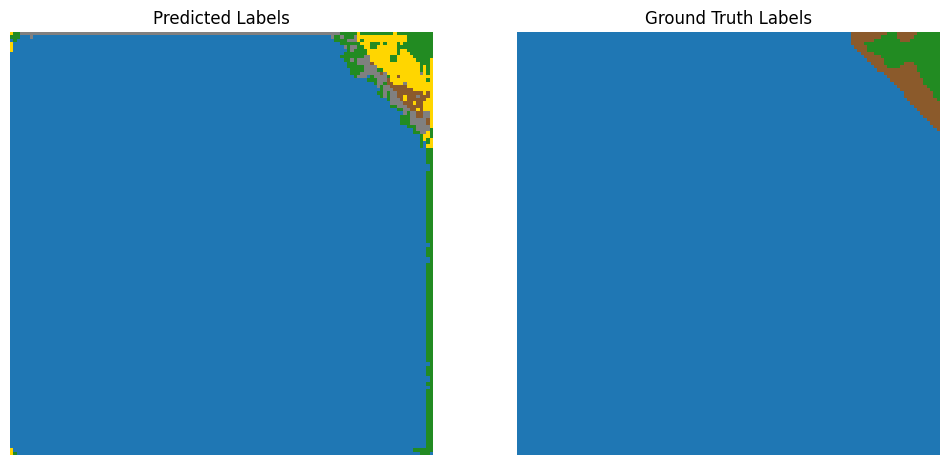

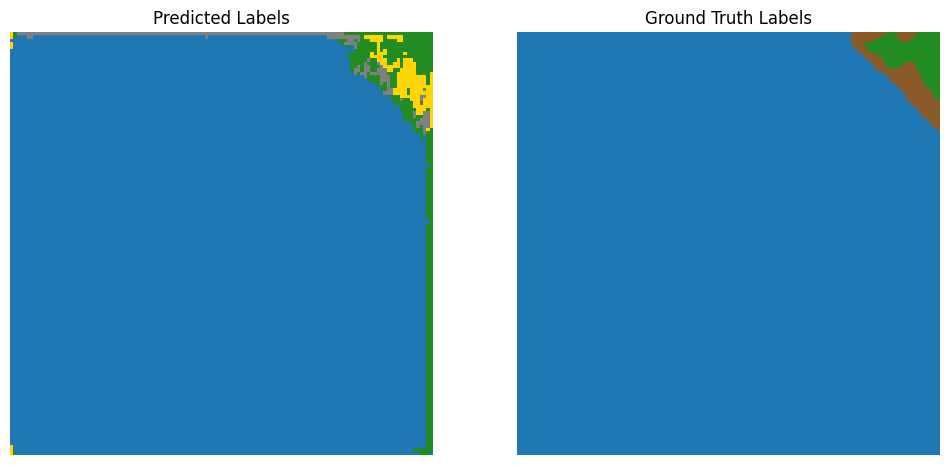

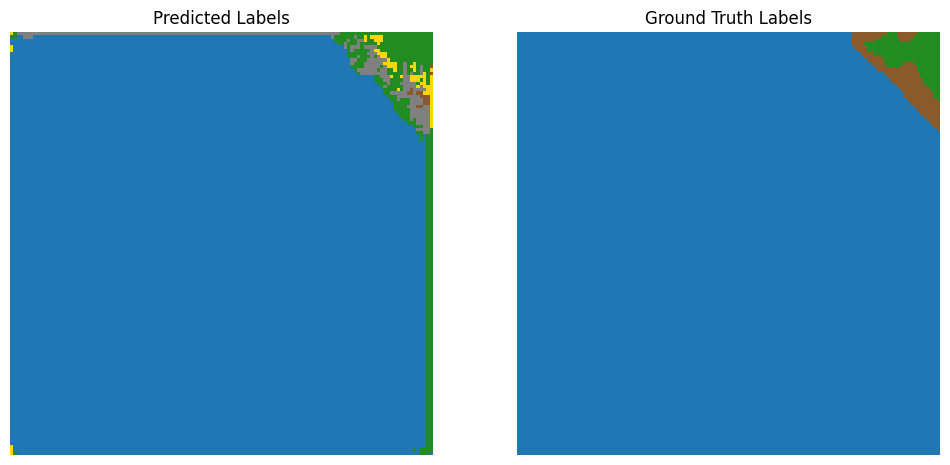

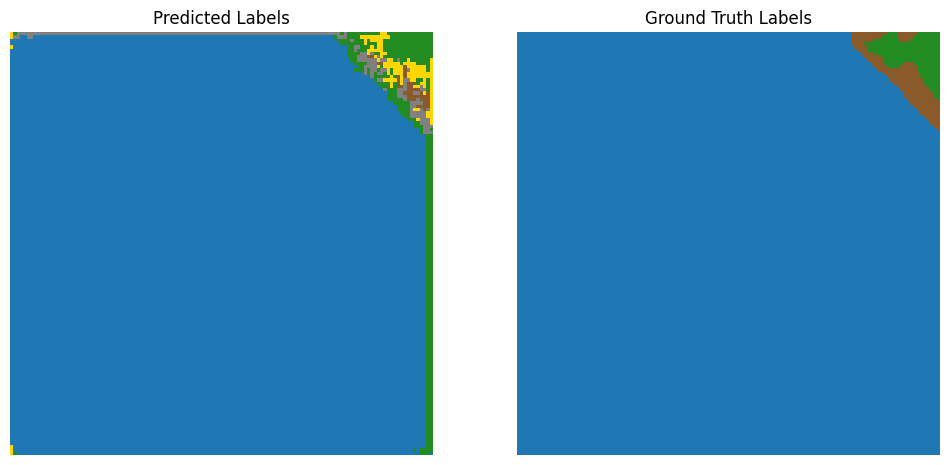

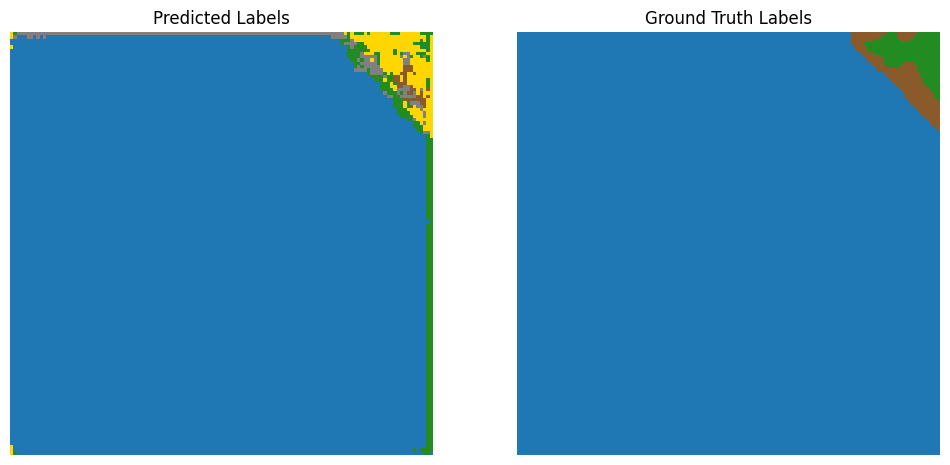

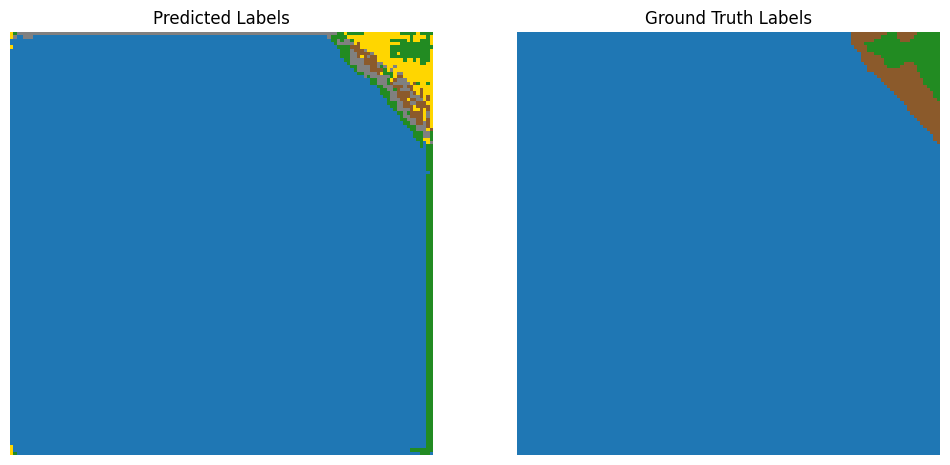

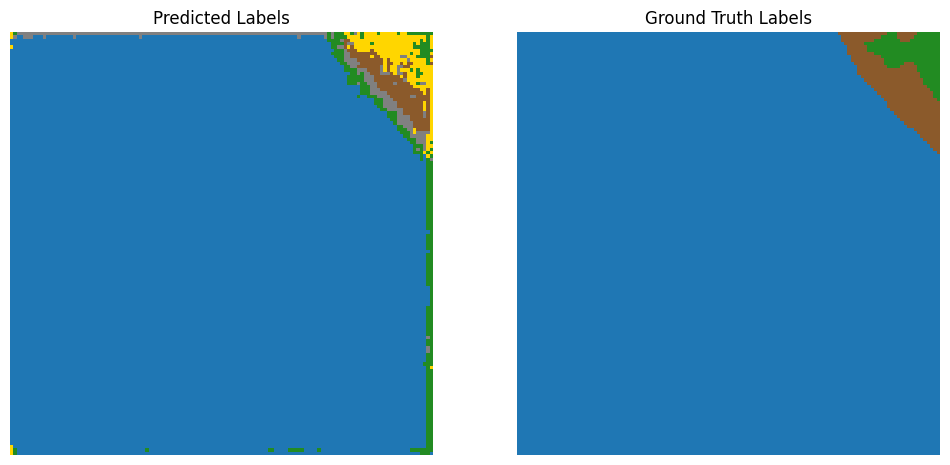

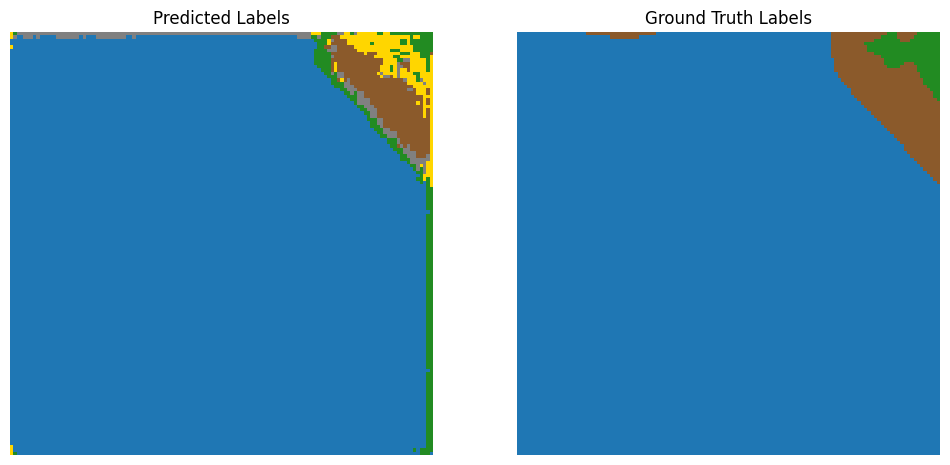

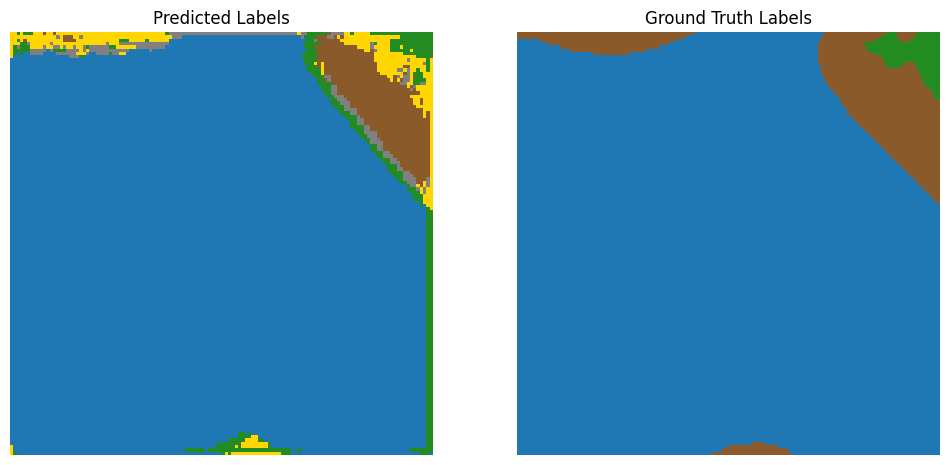

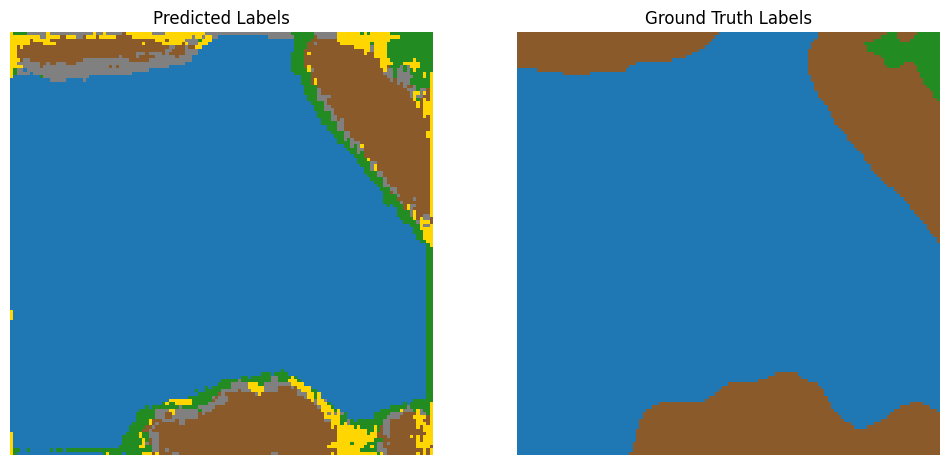

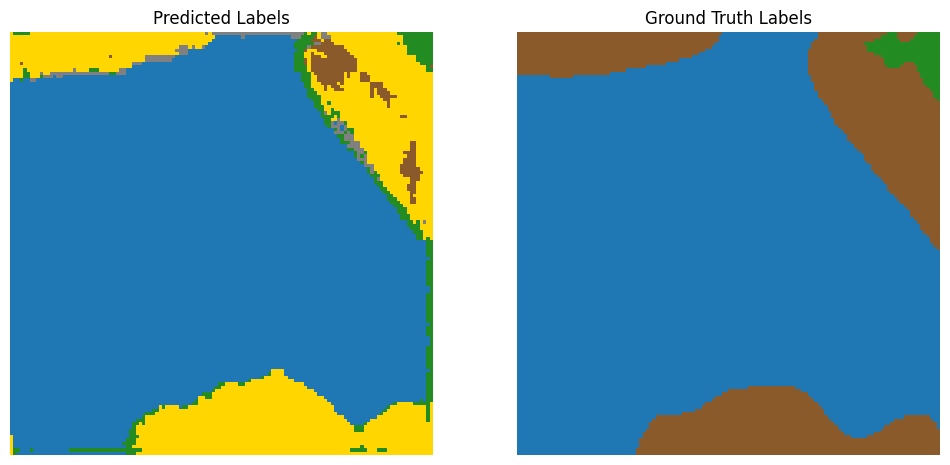

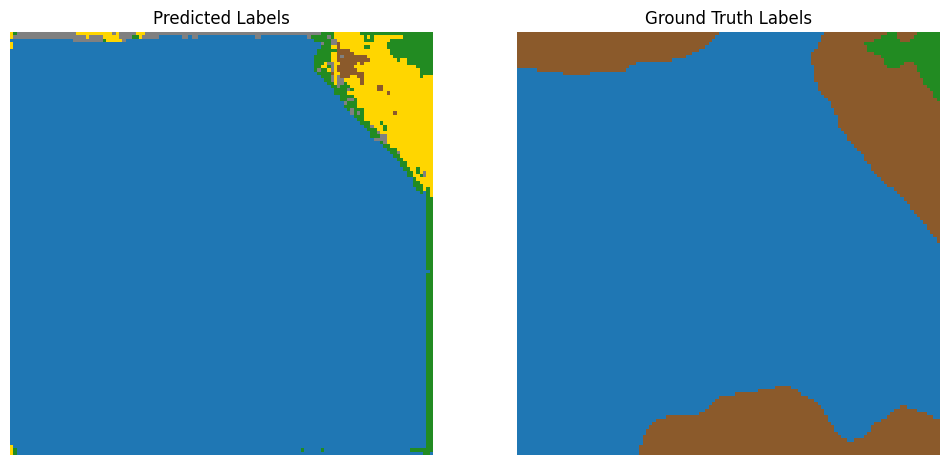

In [60]:
model.eval()
for batch in val_loader:
    train_sample = batch 
    with torch.no_grad():
        output = model(train_sample[0][0])
    pred = output.argmax(dim=1).detach().cpu().numpy()

    rgb_pred = np.zeros((pred.shape[0], pred.shape[1], pred.shape[2], 3), dtype=np.uint8)
    for i in range(5):
        rgb_pred[pred == i] = DYNAMICEARTHNET_CLASSES[i]["color"]
    rgb_labels = np.zeros((train_sample[1][0].shape[0], train_sample[1][0].shape[1], train_sample[1][0].shape[2], 3), dtype=np.uint8)
    for i in range(5):
        rgb_labels[train_sample[1][0].numpy() == i] = DYNAMICEARTHNET_CLASSES[i]["color"]
    for k in range(24):
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(rgb_pred[k])
        plt.title('Predicted Labels')
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(rgb_labels[k])
        plt.title('Ground Truth Labels')
        plt.axis('off')
        plt.show()
    break


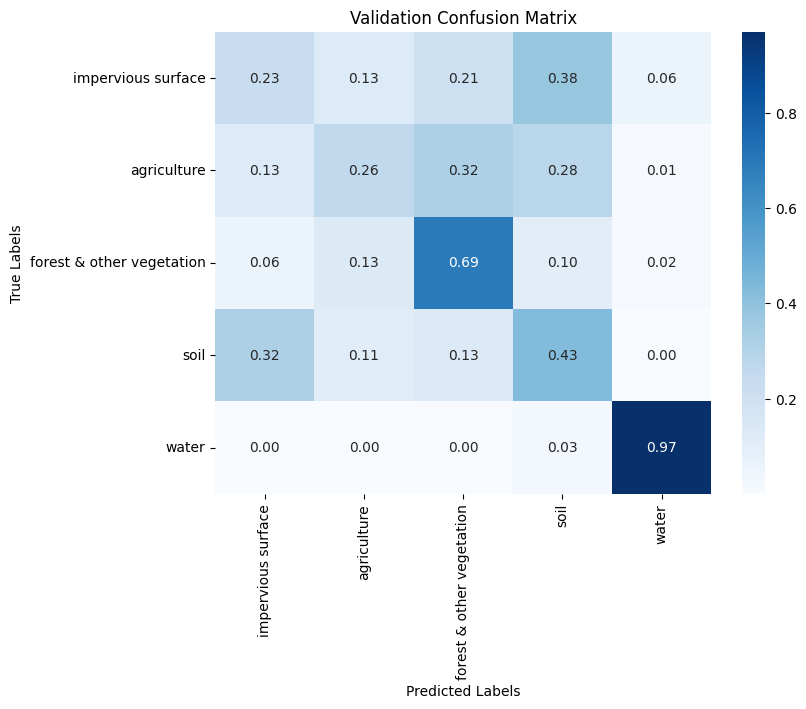

In [63]:
import seaborn as sns

# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = val_conf_matrix.float() / val_conf_matrix.sum(dim=1, keepdim=True)
sns.heatmap(val_conf_matrix_normalized.numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(5)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(5)])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

### Bibliography

[1] Toker et al. _DynamicEarthNet: Daily Multi-Spectral Satellite Dataset for Semantic Change Segmentation_. CVPR 2022.